# Simulació de fotons al voltant d’un forat negre de Schwarzschild

Aquest notebook adapta el programa `ForatNegre.py` a Google Colab.

El programa original està pensat per executar-se com una aplicació interactiva amb `pygame`: l’usuari clica o arrossega el ratolí per llançar fotons, i el programa pinta les trajectòries en una finestra. En aquest notebook, en canvi, fixam unes condicions inicials concretes perquè el lector pugui veure directament les diferents casuístiques sense haver d’interactuar amb el ratolí.

Mostrarem tres casos:

1. Un fotó que passa prop del forat negre però **escapa**.
2. Un fotó que acaba **capturat** pel forat negre.
3. Un fotó amb paràmetre d’impacte molt proper al valor crític, que fa una **quasi òrbita circular** prop de l’esfera de fotons. Numèricament, aquesta òrbita no és estable: després d’alguna volta, el fotó acaba escapant o caient.

In [ ]:
import math
import os
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageDraw
from IPython.display import display

## Constants físiques i visuals

Treballam en unitats geomètriques simplificades. La massa del forat negre és `M`.

En la mètrica de Schwarzschild:

- l’horitzó d’esdeveniments és a `r = 2M`;
- l’esfera de fotons és a `r = 3M`;
- el paràmetre crític d’impacte és

$$
b_{\mathrm{crit}} = 3\sqrt{3}M.
$$

Si un fotó tengués exactament aquest paràmetre i estigués exactament sobre l’esfera de fotons, la teoria prediu una òrbita circular. Però aquesta situació és inestable i, amb errors numèrics o condicions inicials només aproximades, el fotó acabarà escapant o caient.

In [ ]:
# --- CONSTANTS DEL MODEL ---

M = 2.0

R_S = 2 * M                 # Horitzó d'esdeveniments
R_PH = 3 * M                # Esfera de fotons
B_CRIT = 3 * math.sqrt(3) * M

print(f"M = {M}")
print(f"Horitzó d'esdeveniments: r = 2M = {R_S:.3f}")
print(f"Esfera de fotons:        r = 3M = {R_PH:.3f}")
print(f"Paràmetre crític:        bcrit = 3√3 M = {B_CRIT:.3f}")

# Colors semblants als del programa original
TRAJ_DISP = "#00ffc8"   # Cian / verd: dispersió
TRAJ_CAPT = "#ff5050"   # Vermell: captura
TRAJ_CRIT = "#ffdc00"   # Groc: cas crític

M = 2.0
Horitzó d'esdeveniments: r = 2M = 4.000
Esfera de fotons:        r = 3M = 6.000
Paràmetre crític:        bcrit = 3√3 M = 10.392


## Equacions geodèsiques

En el programa original, l’estat d’un fotó es representa com

$$
(r,\phi,p_r,p_\phi).
$$

Aquí:

- `r` és la distància radial al forat negre;
- `phi` és l’angle polar;
- `p_r` és el moment radial;
- `p_phi` és el moment angular, que es conserva.

Les equacions que integram són:

$$
r' = f(r)p_r,
$$

$$
\phi' = \frac{p_\phi}{r^2},
$$

$$
p_r' = \frac{p_\phi^2}{r^3}
-
\frac{M}{r^2}
\left(
\frac{1}{f(r)^2} + p_r^2
\right),
$$

on

$$
f(r)=1-\frac{2M}{r}.
$$

Integrarem aquestes equacions amb Runge-Kutta d’ordre 4, igual que fa el programa original.

In [ ]:
def get_derivatives(state, mass=M):
    """
    Calcula les derivades de l'estat (r, phi, pr, p_phi).

    Aquesta és l'adaptació directa de la funció get_derivatives
    del programa ForatNegre.py.
    """
    r, phi, pr, p_phi = state

    # Si el fotó ja és dins l'horitzó, deixam d'evolucionar-lo.
    if r <= 2.01 * mass:
        return np.array([0.0, 0.0, 0.0, 0.0])

    f = 1.0 - (2.0 * mass / r)

    dr = f * pr
    dphi = p_phi / (r ** 2)

    dpr = (
        (p_phi ** 2 / r ** 3)
        - (mass / r ** 2) * ((1.0 / f ** 2) + pr ** 2)
    )

    return np.array([dr, dphi, dpr, 0.0])


def rk4_step(state, mass=M, h=0.04):
    """
    Un pas del mètode Runge-Kutta de quart ordre.
    """
    state = np.asarray(state, dtype=float)

    k1 = get_derivatives(state, mass)
    k2 = get_derivatives(state + h * k1 / 2, mass)
    k3 = get_derivatives(state + h * k2 / 2, mass)
    k4 = get_derivatives(state + h * k3, mass)

    return state + (h / 6) * (k1 + 2*k2 + 2*k3 + k4)


def calculate_step(r, mass=M):
    """
    Pas d'integració adaptat.

    Prop de l'esfera de fotons, r = 3M, usam un pas més petit
    perquè la dinàmica és més delicada.
    """
    return 0.001 if abs(r - 3 * mass) < 0.1 else 0.04

## Condicions inicials

En el programa interactiu original, l’usuari tria el punt inicial amb el ratolí. Si fa un clic ràpid, el fotó es dispara horitzontalment.

Aquí reproduïm aquesta idea de manera fixa:

- començam el fotó a l’esquerra del forat negre;
- el feim avançar cap a la dreta;
- triem diferents valors de `y0`.

Això fa que el moment angular, i per tant el paràmetre d’impacte, sigui aproximadament el valor `|y0|`.

Si `b` és més gran que `bcrit`, el fotó tendeix a escapar.

Si `b` és més petit que `bcrit`, tendeix a ser capturat.

Si `b` és molt proper a `bcrit`, passa molt prop de l’esfera de fotons i pot fer alguna volta abans de decidir el seu destí.

In [ ]:
def initial_state_horizontal(x0, y0, mass=M):
    """
    Construeix l'estat inicial d'un fotó que surt horitzontalment.

    Això imita el cas de clic ràpid del programa original:
    si el fotó comença a l'esquerra, va cap a la dreta;
    si comença a la dreta, va cap a l'esquerra.
    """
    r0 = math.hypot(x0, y0)

    if r0 <= 2.1 * mass:
        raise ValueError("El fotó comença massa a prop o dins l'horitzó d'esdeveniments.")

    phi0 = math.atan2(y0, x0)

    # Velocitat horitzontal cap al centre
    vx, vy = (1.0 if x0 < 0 else -1.0), 0.0

    # Moment angular
    L = x0 * vy - y0 * vx

    f0 = 1.0 - (2.0 * mass / r0)

    # Moment radial inicial, com al programa original
    pr0 = (vx * (x0 / r0) + vy * (y0 / r0)) / f0

    return np.array([r0, phi0, pr0, L], dtype=float)


def simulate_photon(
    state,
    label="",
    mass=M,
    max_steps=250_000,
    r_escape=150.0,
    keep_every=1
):
    """
    Integra la trajectòria d'un fotó.

    Retorna:
    - punts de la trajectòria en coordenades cartesianes;
    - destí final: escapa, capturat o inacabat.
    """
    st = np.asarray(state, dtype=float)
    rows = []

    fate = "inacabat"

    for i in range(max_steps):
        r, phi, pr, p_phi = st

        x = r * math.cos(phi)
        y = r * math.sin(phi)
        rows.append((x, y, r, phi, pr, p_phi))

        # Captura: el fotó arriba a l'horitzó d'esdeveniments.
        if r <= 2.05 * mass:
            fate = "capturat"
            break

        # Escapada: el fotó torna a una distància molt gran.
        if r > r_escape and i > 50:
            fate = "escapa"
            break

        h = calculate_step(r, mass)
        st = rk4_step(st, mass, h)

    arr = np.array(rows[::keep_every])

    return {
        "label": label,
        "fate": fate,
        "points": arr,
        "steps": i + 1,
        "b": abs(state[3]),
        "final_state": st,
    }

## Imatge de fons

El programa original utilitza una imatge del JWST com a fons. En aquest notebook intentam trobar-la de tres maneres:

1. si existeix un fitxer `JWST.jpg` dins el Colab;
2. si existeix dins una carpeta `images/JWST.jpg`;
3. si no existeix, la descarregam del repositori de GitHub.

A més, aplicam una deformació visual aproximada prop del forat negre per imitar l’efecte de lent gravitatòria del programa original.

Aquesta deformació és visual: les trajectòries físiques són les que hem integrat amb les equacions anteriors.

Fons utilitzat: /content/JWST.jpg
Mida de la imatge: (3844, 2085)


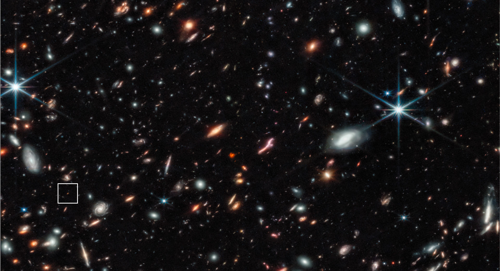

In [ ]:
def load_background_image():
    """
    Carrega JWST.jpg.

    Ordre:
    1. /content/JWST.jpg
    2. ./JWST.jpg
    3. ./images/JWST.jpg
    4. Descàrrega des del GitHub del projecte
    5. Si tot falla, crea un fons d'estrelles procedimental
    """
    candidate_paths = [
        Path("/content/JWST.jpg"),
        Path("JWST.jpg"),
        Path("images/JWST.jpg"),
    ]

    for p in candidate_paths:
        if p.exists():
            return Image.open(p).convert("RGB"), str(p)

    Path("images").mkdir(exist_ok=True)

    github_url = "https://raw.githubusercontent.com/psardf03/ForatNegre/main/images/JWST.jpg"

    try:
        urllib.request.urlretrieve(github_url, "images/JWST.jpg")
        return Image.open("images/JWST.jpg").convert("RGB"), "images/JWST.jpg descarregada de GitHub"

    except Exception as e:
        print("No s'ha trobat JWST.jpg. Es crea un fons procedimental.")
        print("Detall:", e)

        rng = np.random.default_rng(4)
        bg = Image.new("RGB", (950, 700), (5, 5, 10))
        draw = ImageDraw.Draw(bg)

        for _ in range(550):
            x = int(rng.integers(0, bg.size[0]))
            y = int(rng.integers(0, bg.size[1]))
            c = int(rng.integers(150, 255))
            draw.ellipse((x, y, x + 1, y + 1), fill=(c, c, 255))

        return bg, "fons procedimental"


bg_img, bg_source = load_background_image()

print("Fons utilitzat:", bg_source)
print("Mida de la imatge:", bg_img.size)

display(bg_img.resize((500, int(500 * bg_img.size[1] / bg_img.size[0]))))

In [ ]:
def scale_cover_pil(img, width, height):
    """
    Redimensiona i retalla la imatge perquè cobreixi tota la figura.
    """
    src_w, src_h = img.size
    scale = max(width / src_w, height / src_h)

    new_size = (
        max(1, int(src_w * scale)),
        max(1, int(src_h * scale))
    )

    scaled = img.resize(new_size, Image.Resampling.LANCZOS)

    left = (scaled.size[0] - width) // 2
    top = (scaled.size[1] - height) // 2

    return scaled.crop((left, top, left + width, top + height))


def make_lensed_background(img, width=900, height=900, mass=M, scale_pix=12.0):
    """
    Crea un fons amb una deformació visual aproximada prop del forat negre.

    No és un traçat exacte de raigs, sinó un efecte visual inspirat
    en el codi original.
    """
    base = np.asarray(scale_cover_pil(img, width, height)).astype(np.uint8)
    source = base.copy()
    result = source.copy()

    cx, cy = width / 2, height / 2

    yy, xx = np.mgrid[0:height, 0:width].astype(np.float32)

    dx = xx - cx
    dy = yy - cy

    dist = np.sqrt(dx * dx + dy * dy)
    theta = np.arctan2(dy, dx)

    rs_px = 2 * mass * scale_pix
    rph_px = 3 * mass * scale_pix

    shadow_px = rs_px * 0.95
    lens_outer_px = max(rph_px * 2.45, rs_px + 1)

    lens_t = np.clip(
        (lens_outer_px - dist) / (lens_outer_px - shadow_px),
        0.0,
        1.0
    )

    strong_t = np.clip(
        (rph_px * 1.45 - dist) / (rph_px * 1.45 - shadow_px),
        0.0,
        1.0
    )

    mask = (dist < lens_outer_px) & (dist > rs_px * 0.35)

    deflection = (rs_px * rs_px) / np.maximum(dist, rs_px * 0.55)

    src_r = np.maximum(
        1.0,
        dist - deflection * (0.25 + 0.62 * strong_t) * lens_t
    )

    ring_mask = dist < rph_px * 1.14
    src_r = np.where(ring_mask, np.maximum(1.0, src_r * 0.72), src_r)

    arc = 0.006 + 0.060 * (strong_t ** 1.4) + 0.010 * lens_t

    samples = []

    for offset in (-arc, -arc * 0.45, 0, arc * 0.45, arc):
        sample_theta = theta + offset

        sx = np.clip(
            np.rint(cx + np.cos(sample_theta) * src_r).astype(np.int32),
            0,
            width - 1
        )

        sy = np.clip(
            np.rint(cy + np.sin(sample_theta) * src_r).astype(np.int32),
            0,
            height - 1
        )

        samples.append(source[sy, sx])

    lensed = np.maximum.reduce(samples)

    brightness = (1.0 + 0.34 * lens_t)[..., None]
    lensed = np.clip(
        lensed.astype(np.float32) * brightness,
        0,
        255
    ).astype(np.uint8)

    result[mask] = lensed[mask]

    return result


BACKGROUND_CACHE = {}

def get_background_for_zoom(zoom):
    """
    Guarda el fons en memòria per no recalcular-lo cada vegada.
    """
    key = round(float(zoom), 3)

    if key not in BACKGROUND_CACHE:
        n = 900
        scale_pix = n / (2 * zoom)
        BACKGROUND_CACHE[key] = make_lensed_background(
            bg_img,
            width=n,
            height=n,
            mass=M,
            scale_pix=scale_pix
        )

    return BACKGROUND_CACHE[key]

## Definim els tres casos

Ara triem tres condicions inicials.

### Cas 1: dispersió

Començam amb un paràmetre d’impacte més gran que el crític:

$$
b > b_{\mathrm{crit}}.
$$

El fotó es corba per la gravetat del forat negre, però no cau.

### Cas 2: captura

Començam amb un paràmetre d’impacte més petit que el crític:

$$
b < b_{\mathrm{crit}}.
$$

El fotó arriba a l’horitzó d’esdeveniments.

### Cas 3: quasi òrbita circular

Començam amb

$$
b \approx b_{\mathrm{crit}}.
$$

El fotó passa molt prop de l’esfera de fotons. Com que la situació és numèricament inestable, fa algunes voltes i després acaba escapant o caient.

In [ ]:
cases = {
    "escape": {
        "label": "Cas 1 — dispersió: el fotó escapa",
        "state": initial_state_horizontal(x0=-50, y0=14),
        "color": TRAJ_DISP,
        "r_escape": 120,
    },

    "captura": {
        "label": "Cas 2 — captura: el fotó cau al forat negre",
        "state": initial_state_horizontal(x0=-50, y0=6),
        "color": TRAJ_CAPT,
        "r_escape": 120,
    },

    "critic": {
        "label": "Cas 3 — quasi òrbita circular: b ≈ bcrit",
        "state": initial_state_horizontal(x0=-120, y0=B_CRIT),
        "color": TRAJ_CRIT,
        "r_escape": 150,
    },
}

results = {}

for name, case in cases.items():
    results[name] = simulate_photon(
        case["state"],
        label=case["label"],
        r_escape=case["r_escape"],
        keep_every=2
    )

summary = pd.DataFrame([
    {
        "cas": results[name]["label"],
        "destí": results[name]["fate"],
        "b": results[name]["b"],
        "bcrit": B_CRIT,
        "passos RK4": results[name]["steps"],
    }
    for name in results
])

display(summary)

,cas,destí,b,bcrit,passos RK4
0,Cas 1 — dispersió: el fotó escapa,escapa,14.000000,10.392305,4419
1,Cas 2 — captura: el fotó cau al forat negre,capturat,6.000000,10.392305,1420
2,Cas 3 — quasi òrbita circular: b ≈ bcrit,escapa,10.392305,10.392305,19925


## Funcions per dibuixar

Les figures següents mostren:

- el forat negre en negre;
- l’horitzó d’esdeveniments en gris;
- l’esfera de fotons en groc;
- les regions de dispersió i captura de manera aproximada;
- la trajectòria del fotó.

El punt gros indica l’inici de la trajectòria i la creu indica el final.

In [ ]:
def draw_scene(ax, title, trajectories, zoom=35, show_zones=True):
    """
    Dibuixa el forat negre, les regions i les trajectòries.
    """
    ax.set_title(title, fontsize=13, pad=12)
    ax.set_aspect("equal", adjustable="box")

    ax.set_xlim(-zoom, zoom)
    ax.set_ylim(-zoom, zoom)

    # Fons JWST amb efecte visual de lent
    ax.imshow(
        get_background_for_zoom(zoom),
        extent=[-zoom, zoom, -zoom, zoom],
        origin="upper",
        zorder=0
    )

    # Regions aproximades segons el paràmetre crític
    if show_zones:
        ax.axhspan(B_CRIT, zoom, color=TRAJ_DISP, alpha=0.08, zorder=1)
        ax.axhspan(-B_CRIT, B_CRIT, color=TRAJ_CAPT, alpha=0.10, zorder=1)
        ax.axhspan(-zoom, -B_CRIT, color=TRAJ_DISP, alpha=0.08, zorder=1)

        ax.axhline(B_CRIT, color=TRAJ_CRIT, lw=1.3, alpha=0.9, zorder=2)
        ax.axhline(-B_CRIT, color=TRAJ_CRIT, lw=1.3, alpha=0.9, zorder=2)

    # Forat negre i cercles importants
    horizon = plt.Circle((0, 0), R_S, color="black", zorder=5)
    horizon_edge = plt.Circle((0, 0), R_S, fill=False, color="gray", lw=2, zorder=6)
    photon_sphere = plt.Circle((0, 0), R_PH, fill=False, color=TRAJ_CRIT, lw=2, zorder=6)

    ax.add_patch(horizon)
    ax.add_patch(horizon_edge)
    ax.add_patch(photon_sphere)

    # Etiquetes
    ax.text(
        0,
        -R_S - 1.2,
        "2M",
        color="white",
        ha="center",
        va="top",
        fontsize=9,
        zorder=9
    )

    ax.text(
        0,
        R_PH + 0.7,
        "3M",
        color=TRAJ_CRIT,
        ha="center",
        va="bottom",
        fontsize=9,
        zorder=9
    )

    # Trajectòries
    for res, color, label in trajectories:
        pts = res["points"]

        ax.plot(
            pts[:, 0],
            pts[:, 1],
            color=color,
            lw=2.2,
            label=label,
            zorder=7
        )

        # Inici
        ax.scatter(
            pts[0, 0],
            pts[0, 1],
            color=color,
            s=40,
            zorder=8
        )

        # Final
        ax.scatter(
            pts[-1, 0],
            pts[-1, 1],
            color=color,
            s=35,
            marker="x",
            zorder=8
        )

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(alpha=0.2)
    ax.legend(loc="upper right", fontsize=9)


def show_result(name, zoom=35):
    """
    Mostra una figura individual per a un cas concret.
    """
    case = cases[name]
    res = results[name]

    fig, ax = plt.subplots(figsize=(8, 8))

    title = (
        f"{res['label']}\n"
        f"destí = {res['fate']} | "
        f"b = {res['b']:.3f} | "
        f"bcrit = {B_CRIT:.3f}"
    )

    draw_scene(
        ax,
        title,
        [(res, case["color"], res["fate"])],
        zoom=zoom
    )

    plt.show()

# Cas 1: fotó que escapa

En aquest primer cas, el paràmetre d’impacte és superior al valor crític:

$$
b > b_{\mathrm{crit}}.
$$

El fotó es desvia per la curvatura de l’espai-temps, però no s’acosta prou al forat negre per quedar capturat. Per això, després de passar prop del centre, torna a allunyar-se.

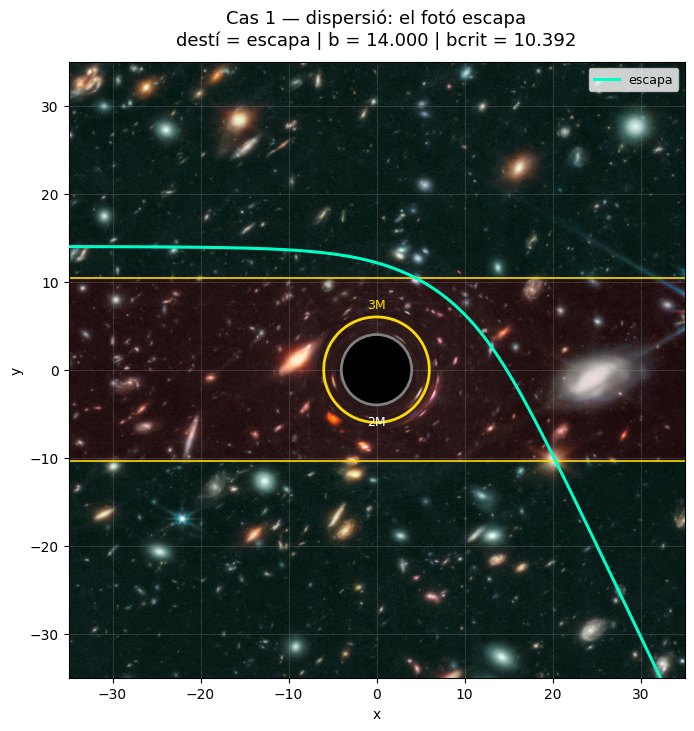

In [ ]:
show_result("escape", zoom=35)

# Cas 2: fotó capturat

En aquest segon cas, el paràmetre d’impacte és inferior al valor crític:

$$
b < b_{\mathrm{crit}}.
$$

El fotó s’acosta massa al forat negre i arriba a l’horitzó d’esdeveniments. En aquest moment deixam de pintar la trajectòria, perquè físicament ja no pot escapar cap a l’exterior.

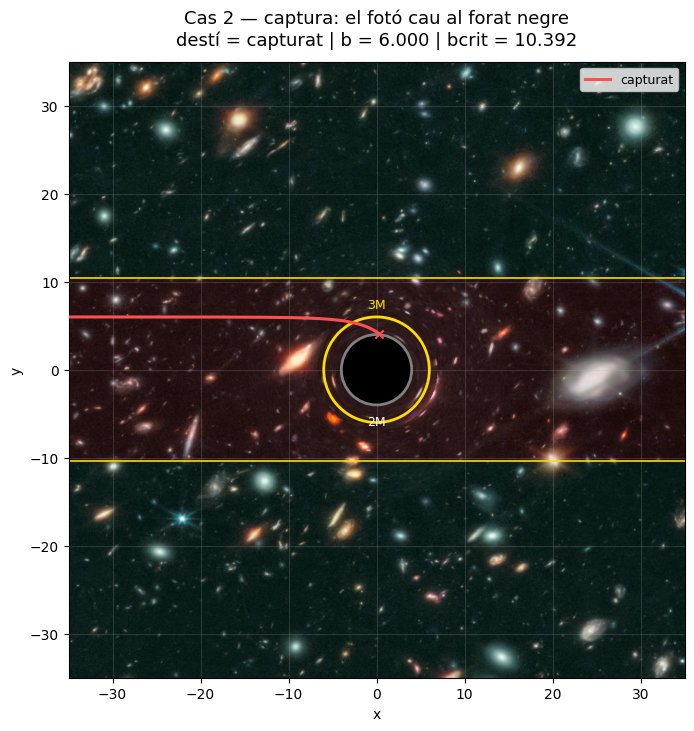

In [ ]:
show_result("captura", zoom=35)

# Cas 3: quasi òrbita circular

Aquest cas és el més delicat.

La teoria diu que, per a

$$
b = b_{\mathrm{crit}} = 3\sqrt{3}M,
$$

un fotó podria quedar en una òrbita circular a l’esfera de fotons, és a dir, a

$$
r = 3M.
$$

Però aquesta òrbita és inestable. A més, en una simulació numèrica, mai no tenim exactament les condicions ideals. Per això el fotó fa algunes voltes prop de l’esfera de fotons i després acaba escapant o caient.

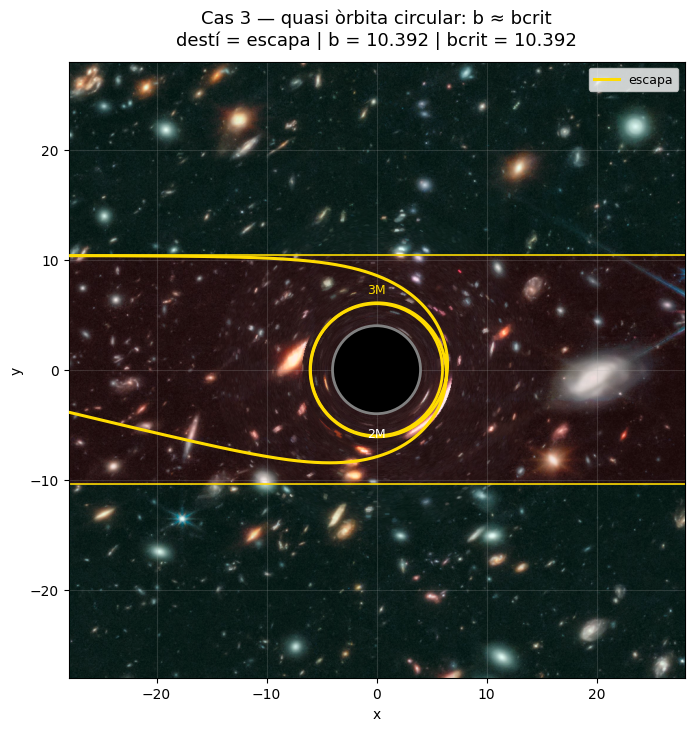

In [ ]:
show_result("critic", zoom=28)

# Comparació final dels tres casos

En una mateixa figura podem comparar les tres casuístiques:

- verd/cian: el fotó escapa;
- vermell: el fotó és capturat;
- groc: trajectòria quasi crítica, propera a l’òrbita circular.

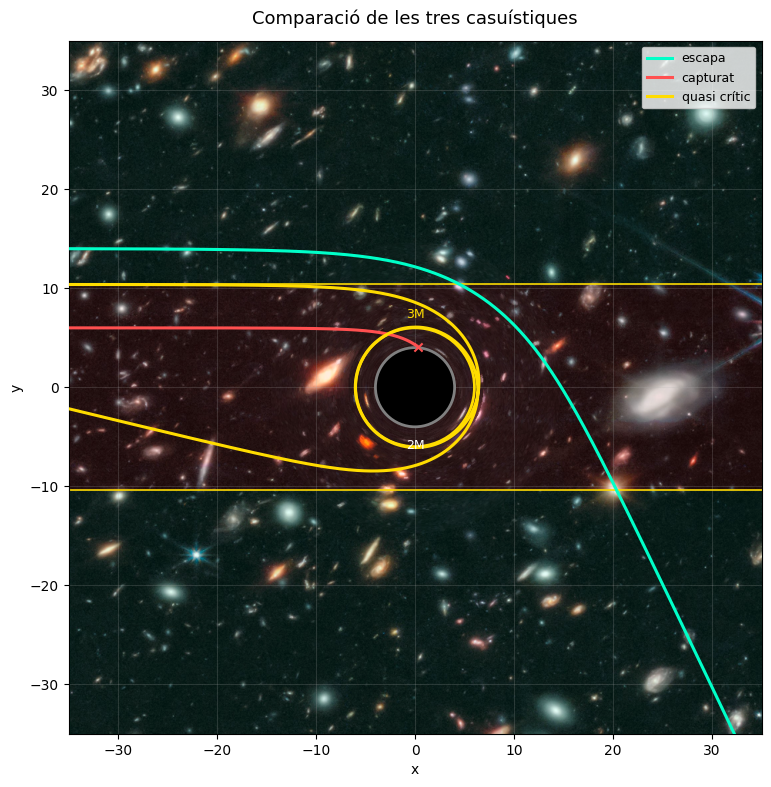

In [ ]:
fig, ax = plt.subplots(figsize=(9, 9))

draw_scene(
    ax,
    "Comparació de les tres casuístiques",
    [
        (results["escape"], TRAJ_DISP, "escapa"),
        (results["captura"], TRAJ_CAPT, "capturat"),
        (results["critic"], TRAJ_CRIT, "quasi crític"),
    ],
    zoom=35
)

plt.show()

# Conclusions

Hem adaptat el programa interactiu `ForatNegre.py` a un format de notebook de Google Colab.

En lloc de dependre del ratolí i d’una finestra `pygame`, hem fixat tres condicions inicials representatives. Això permet que el lector simplement faci scroll i vegi:

1. una trajectòria de dispersió;
2. una trajectòria de captura;
3. una trajectòria quasi crítica propera a l’esfera de fotons.

La part essencial del programa original es conserva: les equacions geodèsiques en coordenades $(r,\phi,p_r,p_\phi)$, el mètode RK4 i la distinció entre horitzó d’esdeveniments, esfera de fotons i paràmetre crític.